## Configurable MAE comparison plotter

Edit `RUN_MODELS` in the following cell.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

records = []

# add records here manually

# Edit this list: (run number or 'run_N', model type or test set, plotted label).
# Use 'base', 'full', or 'transfer' for runs with a single metrics set; use
# 'test_1' or 'test_2' for multi-test-set runs (which plot their base models).
RUN_MODELS = [
]

MODEL_KEYS = {
    'base': 'base_models',
    'full': 'full_high_fidelity_models',
    'transfer': 'transfer_models',
}

# This works whether the notebook is run from the repository root or notebooks/.
output_root = next(
    (path for path in (Path('scripts/output'), Path('../scripts/output')) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError('Run outputs could not be found.')

for run, model_type, label in RUN_MODELS:
    run_name = f'run_{run}' if isinstance(run, int) else str(run)
    if not run_name.startswith('run_'):
        run_name = f'run_{run_name}'
    selector = model_type.lower()

    result_path = output_root / run_name / 'result.json'
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing result file: {result_path}')
    metrics_by_model = json.loads(result_path.read_text()).get('metrics', {})
    if selector in MODEL_KEYS:
        model_key = MODEL_KEYS[selector]
    elif selector in ('test_1', 'test_2'):
        if selector not in metrics_by_model:
            available = ', '.join(metrics_by_model) or 'none'
            raise KeyError(f"{run_name} has no {selector!r} metrics; available: {available}.")
        metrics_by_model = metrics_by_model[selector]
        model_key = MODEL_KEYS['base']
    else:
        raise ValueError(
            f"{run_name}: selector must be 'base', 'full', 'transfer', 'test_1', or 'test_2', not {selector!r}."
        )
    if model_key not in metrics_by_model:
        available = ', '.join(metrics_by_model) or 'none'
        raise KeyError(f"{run_name} has no metrics for {selector!r}; available: {available}.")

    metrics = metrics_by_model[model_key]
    records.append({
        'label': label,
        'energy_mean': metrics['energy_mae_ev']['mean'],
        'energy_std': np.sqrt(metrics['energy_mae_ev']['variance']),
        'force_mean': metrics['force_mae_ev_per_ang']['mean'],
        'force_std': np.sqrt(metrics['force_mae_ev_per_ang']['variance']),
    })

# add records here manually
records.append({'label': 'Augmented grid,\n740 grid geoms with\n10x NMS with manual adjustment',
                'energy_mean': 0.32969213,
                'energy_std': np.sqrt(0),
                'force_mean': 0.647887,
                'force_std': np.sqrt(0),
                })

labels = [record['label'] for record in records]
energy_means = [record['energy_mean'] for record in records]
energy_stds = [record['energy_std'] for record in records]
force_means = [record['force_mean'] for record in records]
force_stds = [record['force_std'] for record in records]
x = np.arange(len(records))
width = 0.38

fig, energy_ax = plt.subplots(figsize=(max(10, 1.8 * len(records)), 5))
force_ax = energy_ax.twinx()
energy_bars = energy_ax.bar(
    x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
    color='#4C78A8', edgecolor='black', label='Energy MAE',
)
force_bars = force_ax.bar(
    x + width / 2, force_means, width, yerr=force_stds, capsize=5,
    color='#F58518', edgecolor='black', label='Force MAE',
)
energy_ax.bar_label(energy_bars, labels=[f'{mean:.4g}' for mean in energy_means], padding=3, fontsize=8)
force_ax.bar_label(force_bars, labels=[f'{mean:.4g}' for mean in force_means], padding=3, fontsize=8)
energy_ax.set_xticks(x, labels, rotation=30, ha='right')
energy_ax.set_title('Ethene models tested on dynamic maxmin data\nEnergy and force MAE (mean ± SD)')
energy_ax.set_ylabel('Energy MAE (eV)', color='#4C78A8')
force_ax.set_ylabel(r'Force MAE (eV/$\AA$)', color='#F58518')
energy_ax.tick_params(axis='y', labelcolor='#4C78A8')
force_ax.tick_params(axis='y', labelcolor='#F58518')
energy_ax.grid(axis='y', alpha=0.25)
#energy_ax.legend(handles=[energy_bars, force_bars], loc='upper right')
fig.tight_layout()
plt.show()


KeyError: "run_15 has no 'test_1' metrics; available: none."

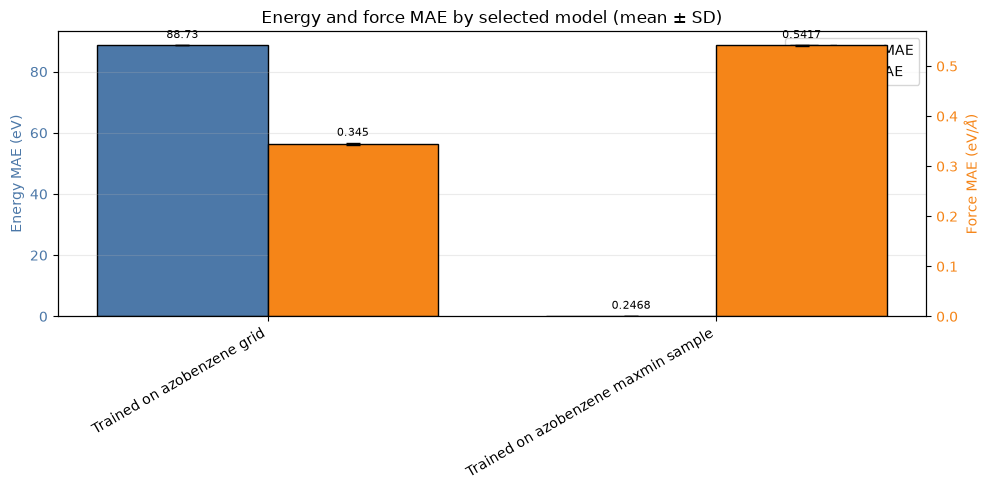

In [3]:
records = [
    {'label': 'Trained on azobenzene grid',
     'energy_mean': 88.7286409,
     'energy_std': np.sqrt(0.00024309),
     'force_mean': 0.3449698,
     'force_std': np.sqrt(4.55023E-06),
     },
     {'label': 'Trained on azobenzene maxmin sample',
      'energy_mean': 0.246786051,
      'energy_std': np.sqrt(1.23964E-07),
      'force_mean': 0.541711963,
      'force_std': np.sqrt(3.69648E-07),
      }
]

labels = [record['label'] for record in records]
energy_means = [record['energy_mean'] for record in records]
energy_stds = [record['energy_std'] for record in records]
force_means = [record['force_mean'] for record in records]
force_stds = [record['force_std'] for record in records]
x = np.arange(len(records))
width = 0.38

fig, energy_ax = plt.subplots(figsize=(max(10, 1.8 * len(records)), 5))
force_ax = energy_ax.twinx()
energy_bars = energy_ax.bar(
    x - width / 2, energy_means, width, yerr=energy_stds, capsize=5,
    color='#4C78A8', edgecolor='black', label='Energy MAE',
)
force_bars = force_ax.bar(
    x + width / 2, force_means, width, yerr=force_stds, capsize=5,
    color='#F58518', edgecolor='black', label='Force MAE',
)
energy_ax.bar_label(energy_bars, labels=[f'{mean:.4g}' for mean in energy_means], padding=3, fontsize=8)
force_ax.bar_label(force_bars, labels=[f'{mean:.4g}' for mean in force_means], padding=3, fontsize=8)
energy_ax.set_xticks(x, labels, rotation=30, ha='right')
energy_ax.set_title('Energy and force MAE by selected model (mean ± SD)')
energy_ax.set_ylabel('Energy MAE (eV)', color='#4C78A8')
force_ax.set_ylabel(r'Force MAE (eV/$\AA$)', color='#F58518')
energy_ax.tick_params(axis='y', labelcolor='#4C78A8')
force_ax.tick_params(axis='y', labelcolor='#F58518')
energy_ax.grid(axis='y', alpha=0.25)
energy_ax.legend(handles=[energy_bars, force_bars], loc='upper right')
fig.tight_layout()
plt.show()

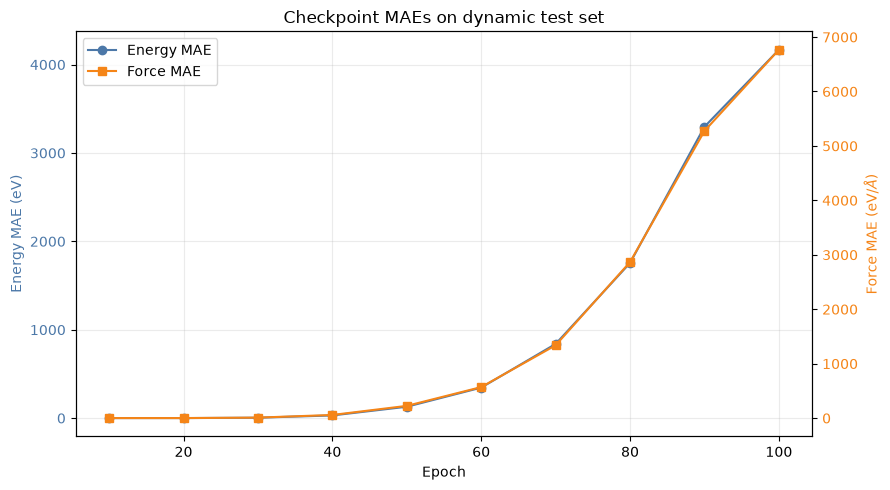

In [9]:
# Plot checkpoint MAEs on run_12's primary test set (test_1).
run_12_path = next(
    (path for path in (Path('scripts/output/run_12/result.json'),
                       Path('../scripts/output/run_12/result.json')) if path.is_file()),
    None,
)
if run_12_path is None:
    raise FileNotFoundError('run_12/result.json could not be found.')

checkpoint_models = json.loads(run_12_path.read_text())['stages']['lf']['history']['checkpoint_models']
epochs = [checkpoint['epoch'] for checkpoint in checkpoint_models]
energy_maes = [checkpoint['test_energy_mae'] for checkpoint in checkpoint_models]
force_maes = [checkpoint['test_force_mae'] for checkpoint in checkpoint_models]

fig, energy_ax = plt.subplots(figsize=(9, 5))
force_ax = energy_ax.twinx()
energy_line = energy_ax.plot(epochs, energy_maes, marker='o', color='#4C78A8', label='Energy MAE')
force_line = force_ax.plot(epochs, force_maes, marker='s', color='#F58518', label='Force MAE')
energy_ax.set_title('Checkpoint MAEs on dynamic test set')
energy_ax.set_xlabel('Epoch')
energy_ax.set_ylabel('Energy MAE (eV)', color='#4C78A8')
force_ax.set_ylabel(r'Force MAE (eV/$\AA$)', color='#F58518')
energy_ax.tick_params(axis='y', labelcolor='#4C78A8')
force_ax.tick_params(axis='y', labelcolor='#F58518')
energy_ax.grid(alpha=0.25)
energy_ax.legend(energy_line + force_line, ['Energy MAE', 'Force MAE'], loc='upper left')
fig.tight_layout()
plt.show()

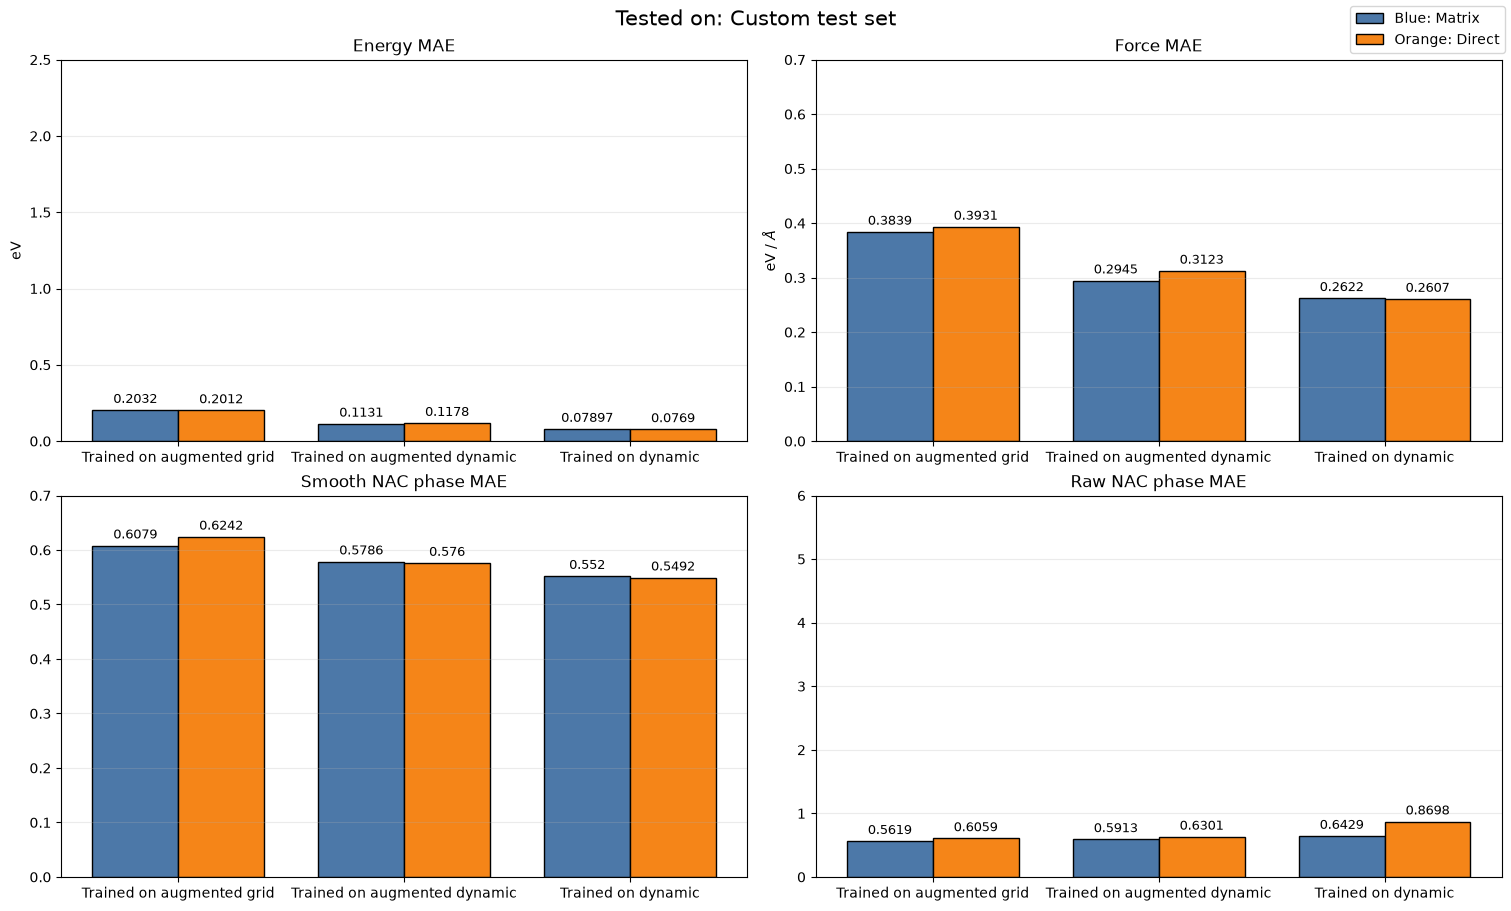

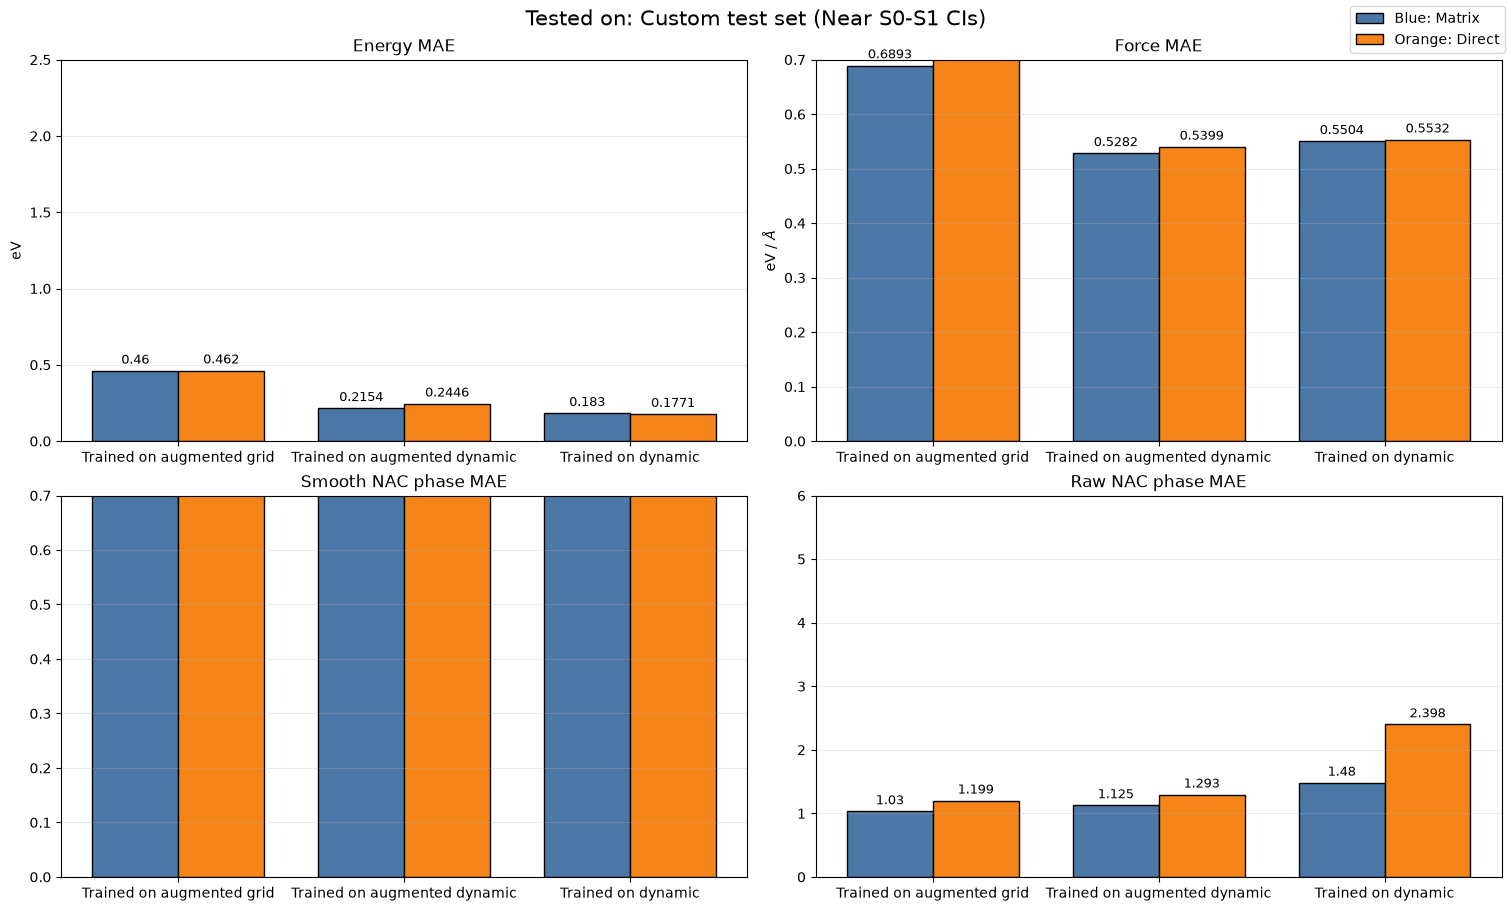

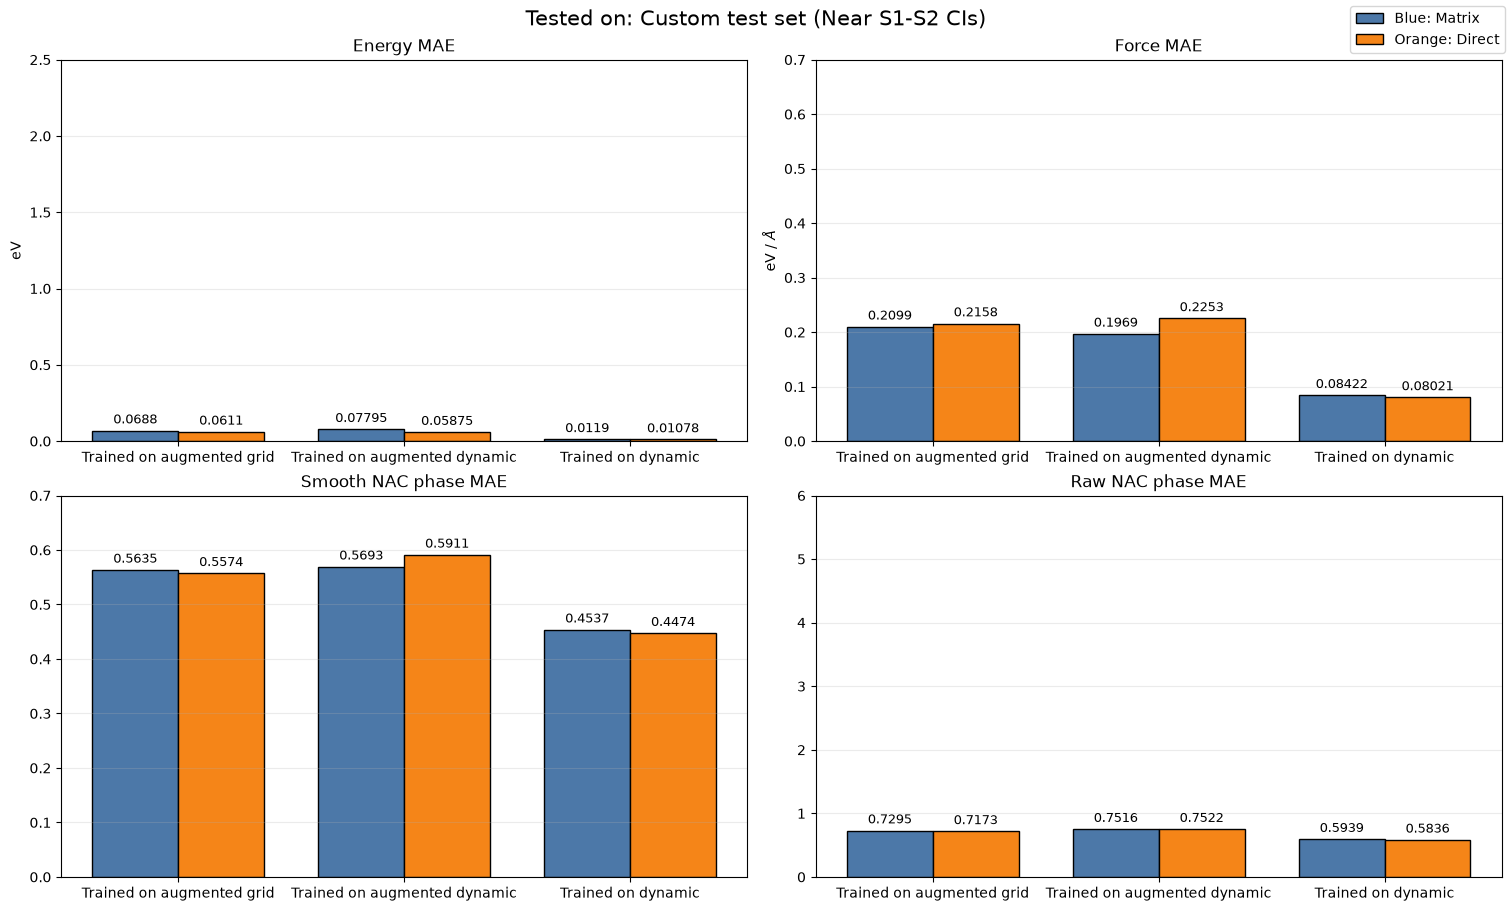

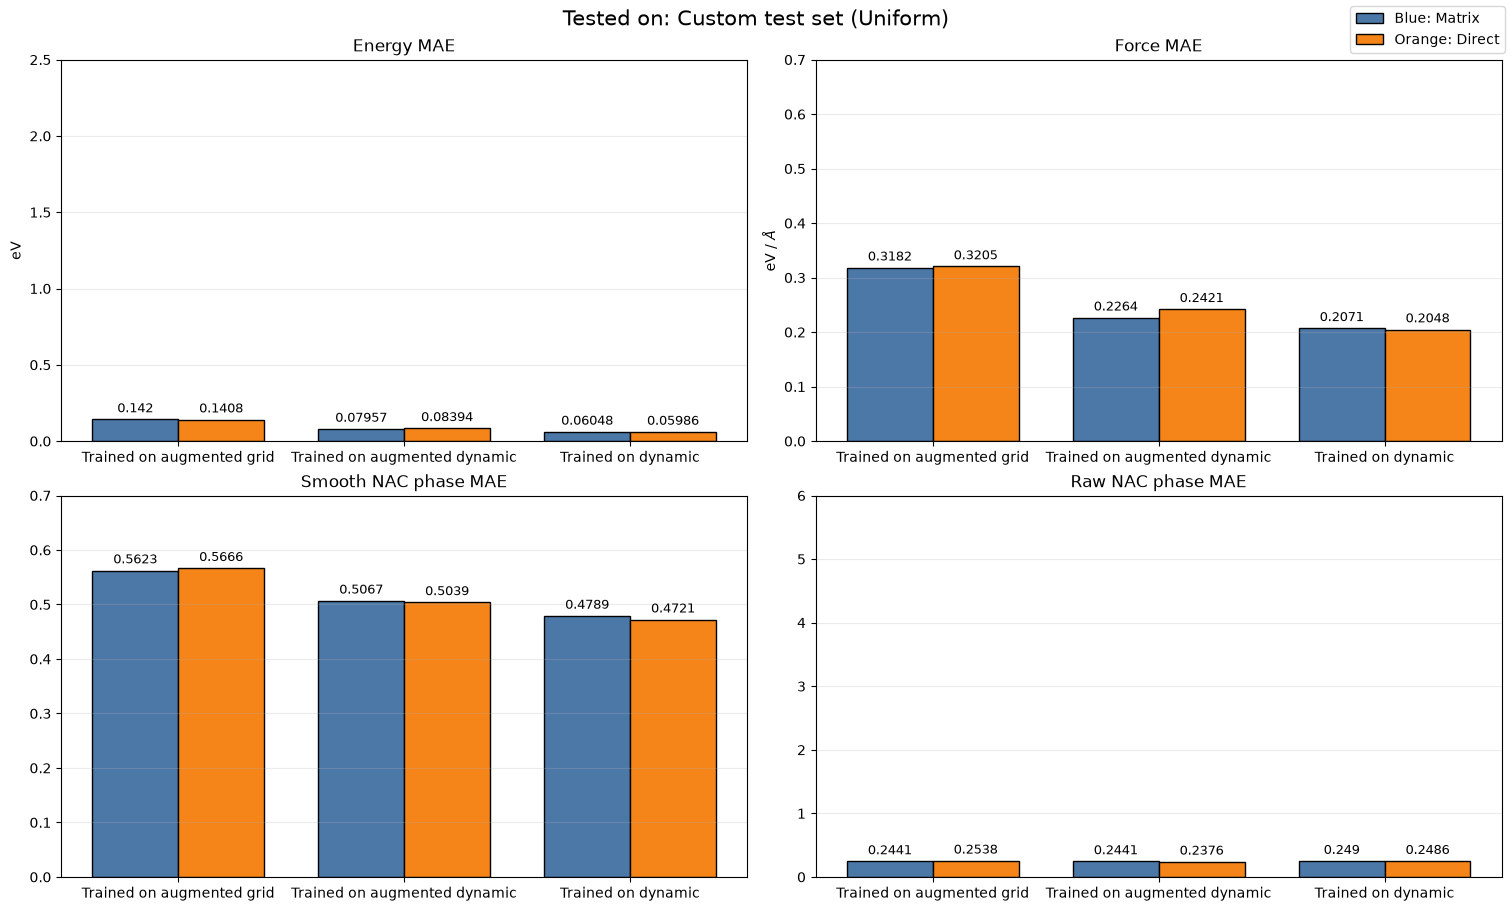

In [13]:
# Fold-1 metric bar histograms for paired runs.
# Edit RUN_LABELS, TEST_LABELS, and RUN_PAIRS to customize labels, titles, and pairs.
import json
from pathlib import Path

import matplotlib.pyplot as plt

RUN_PAIRS = [(15, 18), (16, 19), (17, 20)]  # blue, orange
RUNS = [run for pair in RUN_PAIRS for run in pair]
TESTS = ['test_1', 'test_2', 'test_3', 'test_4']

# Each label can be edited independently for every run and test.
RUN_LABELS = {
    15: {'test_1': 'Trained on augmented grid', 'test_2': 'Trained on augmented grid', 'test_3': 'Trained on augmented grid', 'test_4': 'Trained on augmented grid'},
    16: {'test_1': 'Trained on augmented dynamic', 'test_2': 'Trained on augmented dynamic', 'test_3': 'Trained on augmented dynamic', 'test_4': 'Trained on augmented dynamic'},
    17: {'test_1': 'Trained on dynamic', 'test_2': 'Trained on dynamic', 'test_3': 'Trained on dynamic', 'test_4': 'Trained on dynamic'},
    18: {'test_1': 'Run 18', 'test_2': 'Run 18', 'test_3': 'Run 18', 'test_4': 'Run 18'},
    19: {'test_1': 'Run 19', 'test_2': 'Run 19', 'test_3': 'Run 19', 'test_4': 'Run 19'},
    20: {'test_1': 'Run 20', 'test_2': 'Run 20', 'test_3': 'Run 20', 'test_4': 'Run 20'},
}
TEST_LABELS = {
    'test_1': 'Custom test set',
    'test_2': 'Custom test set (Near S0-S1 CIs)',
    'test_3': 'Custom test set (Near S1-S2 CIs)',
    'test_4': 'Custom test set (Uniform)'
}

METRICS = {
    'energy_mae_ev': ('Energy MAE', 'eV'),
    'force_mae_ev_per_ang': ('Force MAE', r'eV / $\AA$'),
    'smooth_nac_phase_mae': ('Smooth NAC phase MAE', ''),
    'raw_nac_phase_mae': ('Raw NAC phase MAE', ''),
}
YLIMS = {
    'energy_mae_ev': (0, 2.5),
    'force_mae_ev_per_ang': (0, 0.7),
    'smooth_nac_phase_mae': (0, 0.7),
    'raw_nac_phase_mae': (0, 6),
}

output_root = next(
    (path for path in (Path('scripts/output'), Path('../scripts/output')) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError('Run outputs could not be found.')

results = {}
for run in RUNS:
    result_path = output_root / f'run_{run}' / 'result.json'
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing result file: {result_path}')
    results[run] = json.loads(result_path.read_text(encoding='utf-8'))

for test_name in TESTS:
    values = {metric_key: {} for metric_key in METRICS}
    for run in RUNS:
        try:
            metrics = results[run]['stages']['lf']['folds']['fold_1']['test_metrics'][test_name]
        except KeyError as error:
            raise KeyError(f'run_{run} is missing fold_1 metrics for {test_name}.') from error
        for metric_key in METRICS:
            values[metric_key][run] = metrics[metric_key]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    for axis, (metric_key, (metric_label, unit)) in zip(axes.flat, METRICS.items()):
        pair_positions = list(range(len(RUN_PAIRS)))
        first_runs = [pair[0] for pair in RUN_PAIRS]
        second_runs = [pair[1] for pair in RUN_PAIRS]
        first_bars = axis.bar(
            [position - 0.19 for position in pair_positions],
            [values[metric_key][run] for run in first_runs],
            width=0.38, color='#4C78A8', edgecolor='black', label='Blue: Matrix',
        )
        second_bars = axis.bar(
            [position + 0.19 for position in pair_positions],
            [values[metric_key][run] for run in second_runs],
            width=0.38, color='#F58518', edgecolor='black', label='Orange: Direct',
        )
        axis.bar_label(first_bars, fmt='%.4g', padding=3, fontsize=9)
        axis.bar_label(second_bars, fmt='%.4g', padding=3, fontsize=9)
        axis.set_xticks(pair_positions, [
            f"{RUN_LABELS[first_run][test_name]}"
            for first_run, second_run in RUN_PAIRS
        ])
        axis.set_title(metric_label)
        axis.set_ylabel(unit)
        axis.set_ylim(YLIMS[metric_key])
        axis.grid(axis='y', alpha=0.25)
        axis.tick_params(axis='x', rotation=0)
    fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper right')
    fig.suptitle(f"Tested on: {TEST_LABELS[test_name]}", fontsize=15)
    plt.show()


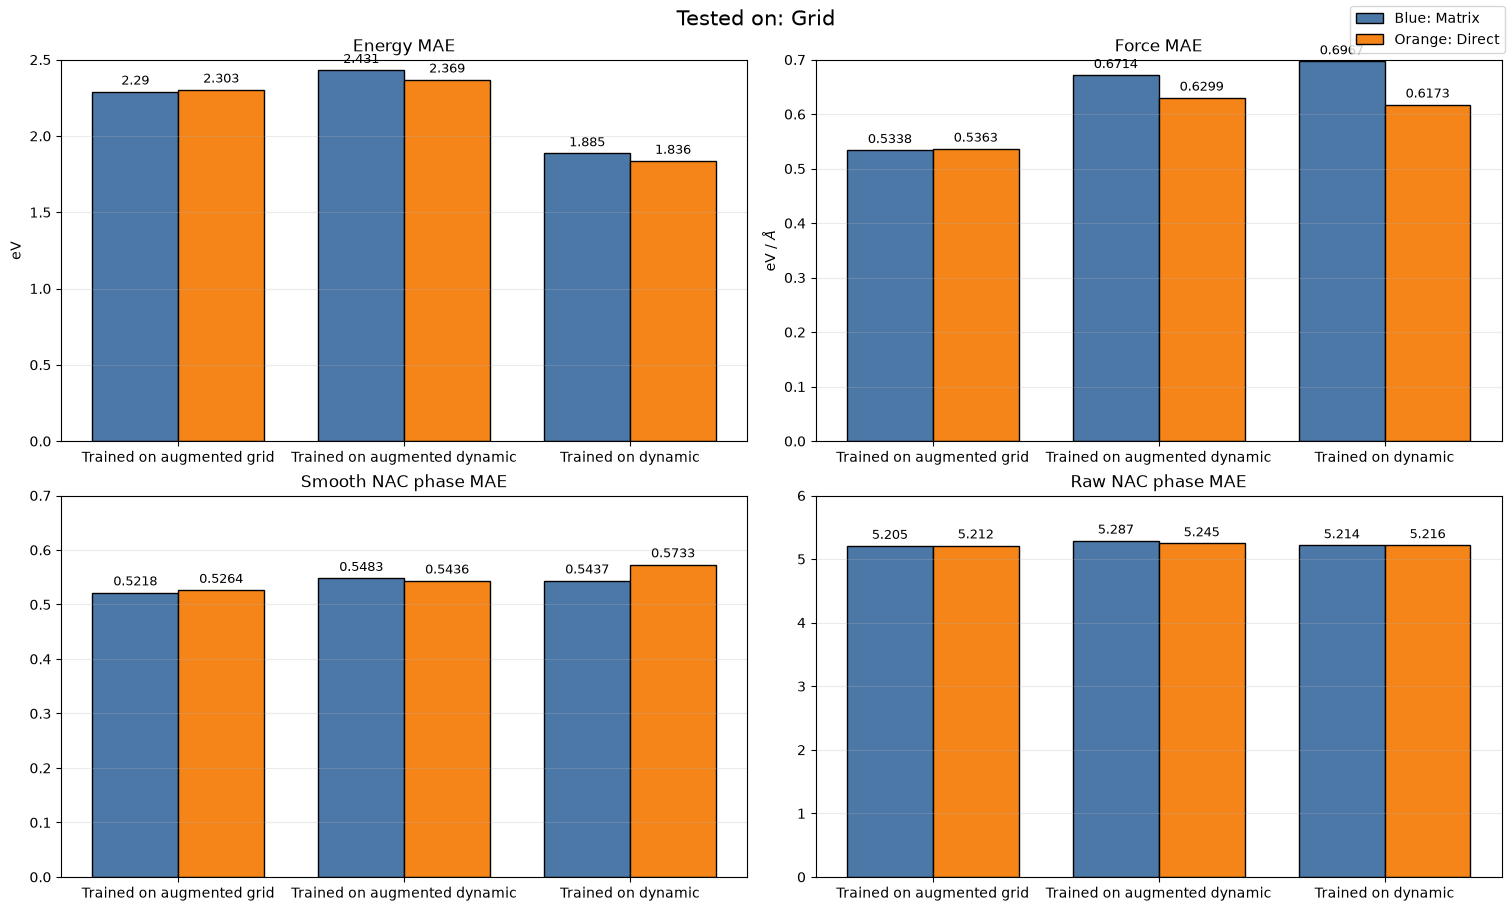

In [14]:
# Manual grid-test MAE entry. Replace every None below with the corresponding MAE.
import matplotlib.pyplot as plt

RUN_PAIRS = [(15, 18), (16, 19), (17, 20)]  # blue, orange
RUN_LABELS = {
    15: 'Trained on augmented grid',
    16: 'Trained on augmented dynamic',
    17: 'Trained on dynamic',
    18: 'Run 18',
    19: 'Run 19',
    20: 'Run 20',
}
GRID_TEST_LABEL = 'Grid'  # Edit the figure title.

# Enter the four MAEs for each run here.
GRID_TEST_MAES = {
    15: {'energy_mae_ev': 2.2897732, 'force_mae_ev_per_ang': 0.5338054, 'smooth_nac_phase_mae': 0.5218276381492615, 'raw_nac_phase_mae': 5.204527854919434},
    16: {'energy_mae_ev': 2.4310873, 'force_mae_ev_per_ang': 0.6714452, 'smooth_nac_phase_mae': 0.5483177304267883, 'raw_nac_phase_mae': 5.2870330810546875},
    17: {'energy_mae_ev': 1.8852063, 'force_mae_ev_per_ang': 0.6967122, 'smooth_nac_phase_mae': 0.5436989068984985, 'raw_nac_phase_mae': 5.213987350463867},
    18: {'energy_mae_ev': 2.3027737, 'force_mae_ev_per_ang': 0.53626937, 'smooth_nac_phase_mae': 0.5264402627944946, 'raw_nac_phase_mae': 5.211886882781982},
    19: {'energy_mae_ev': 2.3686476, 'force_mae_ev_per_ang': 0.62994456, 'smooth_nac_phase_mae': 0.5435513257980347, 'raw_nac_phase_mae': 5.245264053344727},
    20: {'energy_mae_ev': 1.8358666, 'force_mae_ev_per_ang': 0.6172772, 'smooth_nac_phase_mae': 0.5733281970024109, 'raw_nac_phase_mae': 5.216135025024414},
}

METRICS = {
    'energy_mae_ev': ('Energy MAE', 'eV'),
    'force_mae_ev_per_ang': ('Force MAE', r'eV / $\AA$'),
    'smooth_nac_phase_mae': ('Smooth NAC phase MAE', ''),
    'raw_nac_phase_mae': ('Raw NAC phase MAE', ''),
}
YLIMS = {
    'energy_mae_ev': (0, 2.5),
    'force_mae_ev_per_ang': (0, 0.7),
    'smooth_nac_phase_mae': (0, 0.7),
    'raw_nac_phase_mae': (0, 6),
}

runs = [run for pair in RUN_PAIRS for run in pair]
missing = [
    f'run_{run}: {metric_key}'
    for run in runs
    for metric_key in METRICS
    if GRID_TEST_MAES[run][metric_key] is None
]
if missing:
    raise ValueError('Enter all grid-test MAEs before plotting: ' + ', '.join(missing))

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
pair_positions = list(range(len(RUN_PAIRS)))
first_runs = [pair[0] for pair in RUN_PAIRS]
second_runs = [pair[1] for pair in RUN_PAIRS]
for axis, (metric_key, (metric_label, unit)) in zip(axes.flat, METRICS.items()):
    first_bars = axis.bar(
        [position - 0.19 for position in pair_positions],
        [GRID_TEST_MAES[run][metric_key] for run in first_runs],
        width=0.38, color='#4C78A8', edgecolor='black', label='Blue: Matrix',
    )
    second_bars = axis.bar(
        [position + 0.19 for position in pair_positions],
        [GRID_TEST_MAES[run][metric_key] for run in second_runs],
        width=0.38, color='#F58518', edgecolor='black', label='Orange: Direct',
    )
    axis.bar_label(first_bars, fmt='%.4g', padding=3, fontsize=9)
    axis.bar_label(second_bars, fmt='%.4g', padding=3, fontsize=9)
    axis.set_xticks(pair_positions, [RUN_LABELS[first_run] for first_run, _ in RUN_PAIRS])
    axis.set_title(metric_label)
    axis.set_ylabel(unit)
    axis.set_ylim(YLIMS[metric_key])
    axis.grid(axis='y', alpha=0.25)
    axis.tick_params(axis='x', rotation=0)

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper right')
fig.suptitle(f'Tested on: {GRID_TEST_LABEL}', fontsize=15)
plt.show()


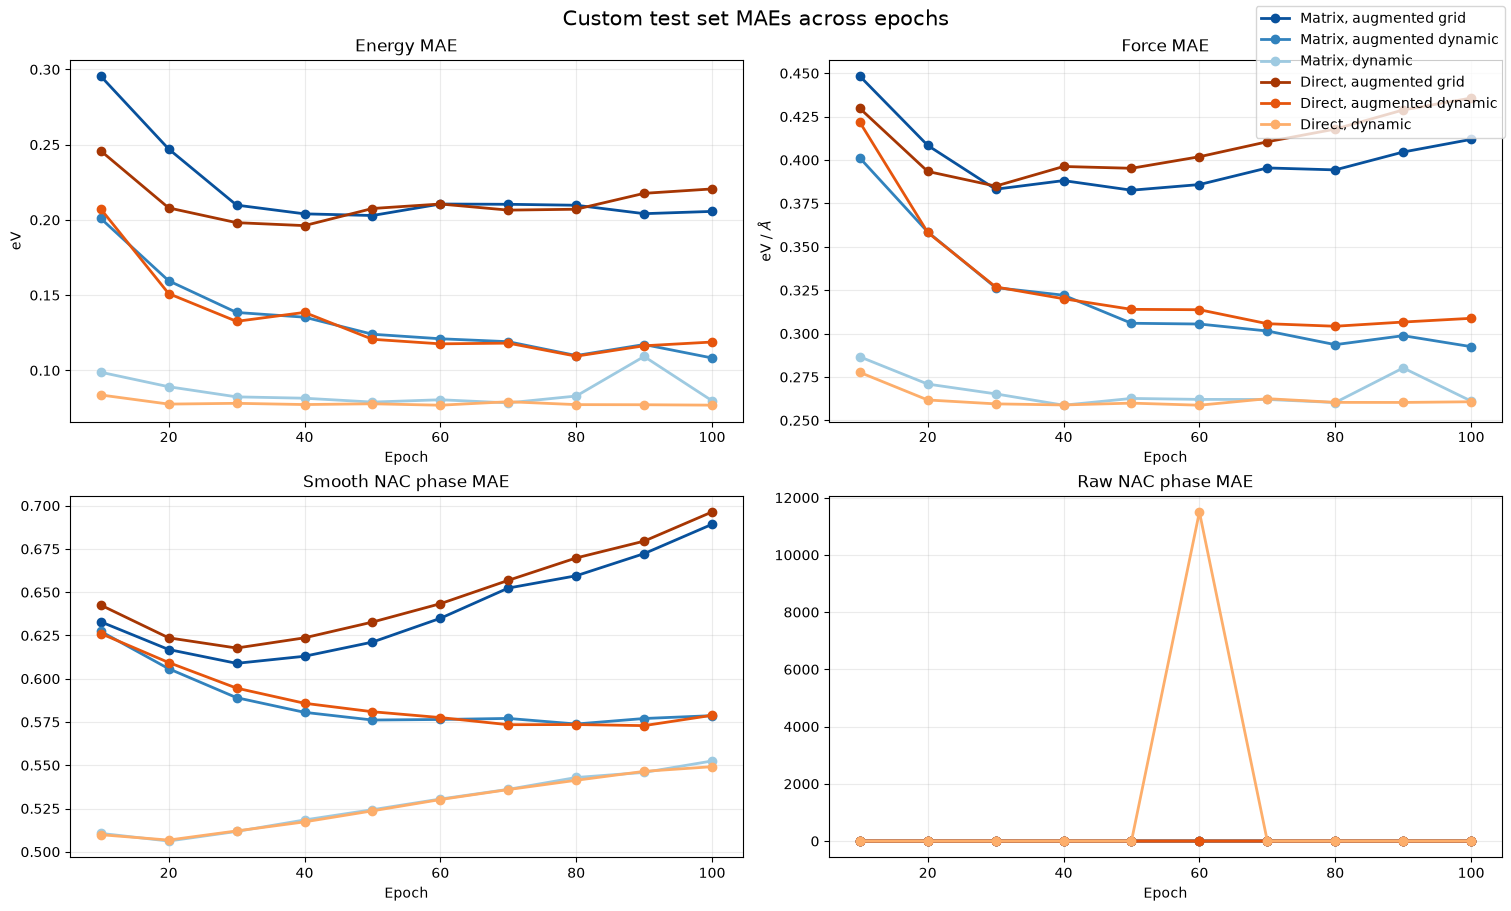

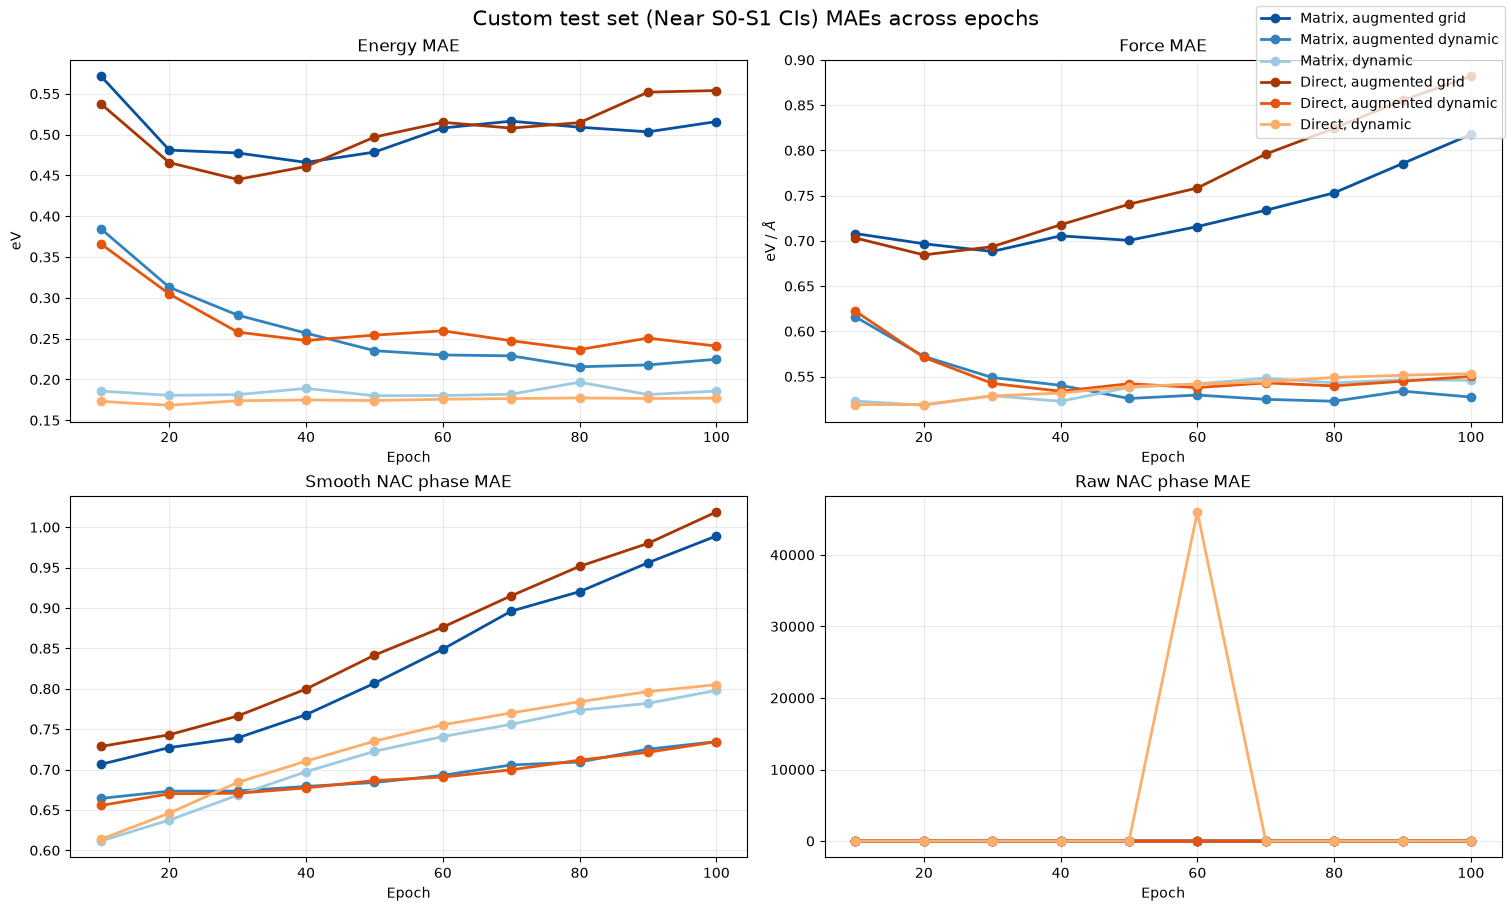

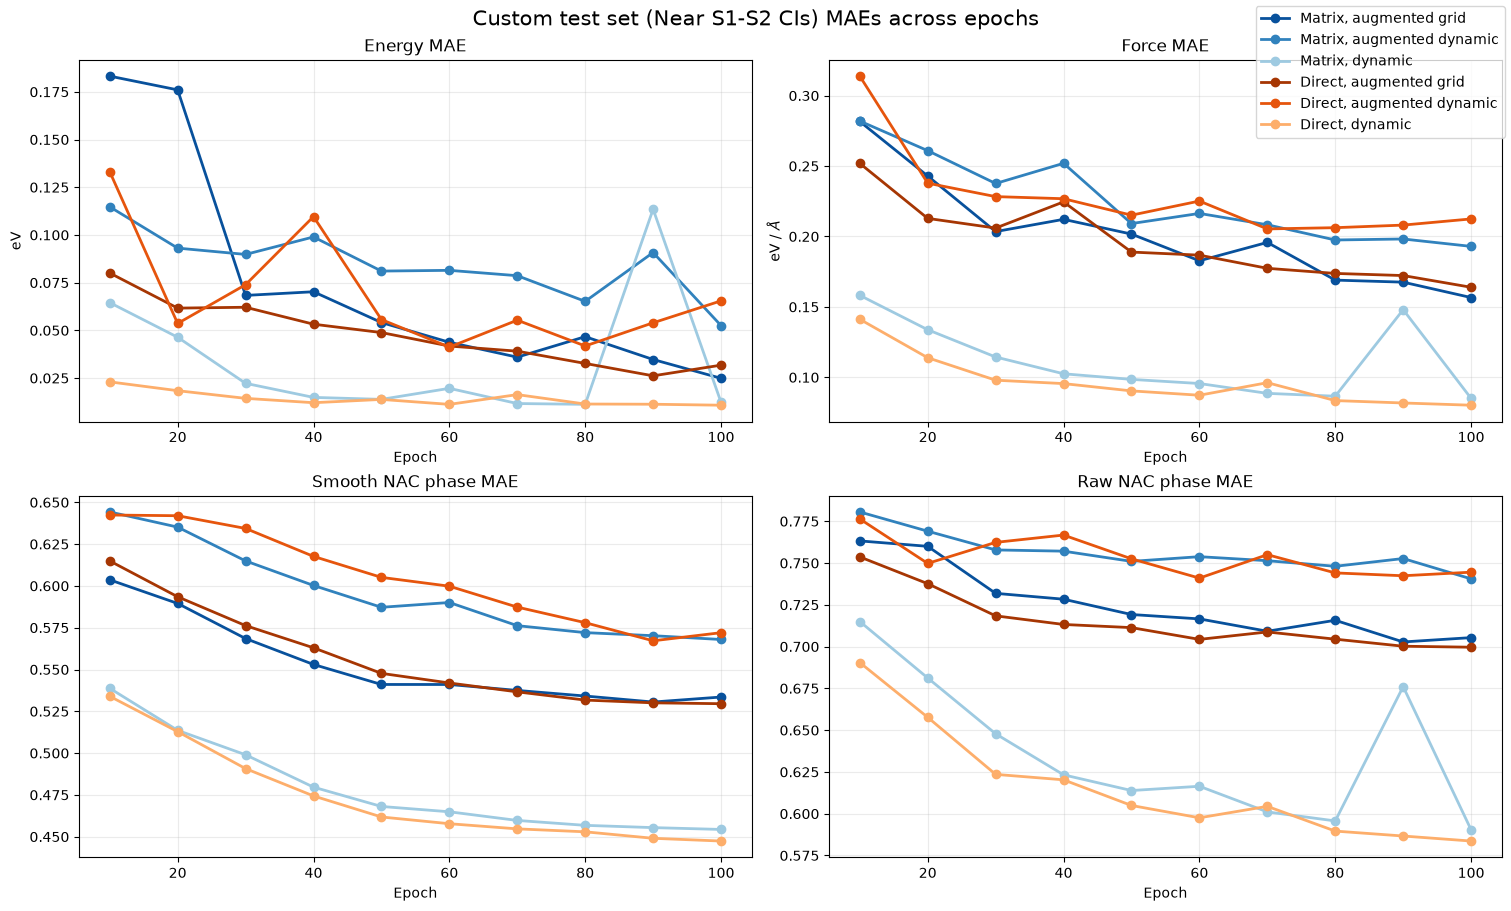

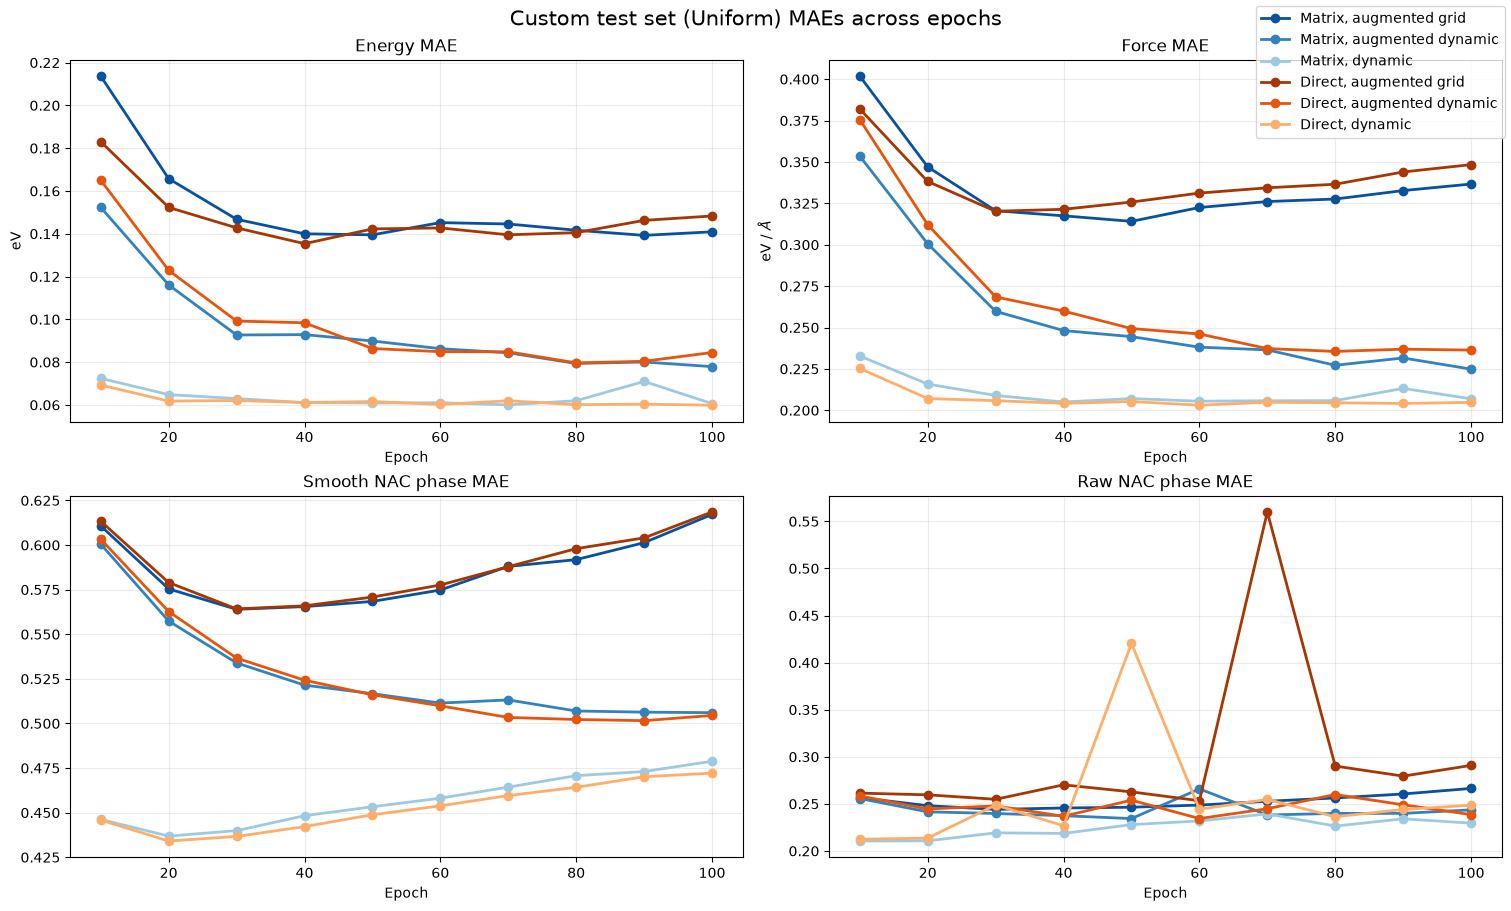

In [9]:
# Checkpoint MAEs across epochs for runs 15–20 and all four test sets.
import json
from pathlib import Path

import matplotlib.pyplot as plt

RUNS = [15, 16, 17, 18, 19, 20]  # Edit as needed.
RUN_LABELS = {
    15: 'Matrix, augmented grid',
    16: 'Matrix, augmented dynamic',
    17: 'Matrix, dynamic',
    18: 'Direct, augmented grid',
    19: 'Direct, augmented dynamic',
    20: 'Direct, dynamic',
}
RUN_COLORS = {
    15: '#08519C',  # dark blue
    16: '#3182BD',  # medium blue
    17: '#9ECAE1',  # light blue
    18: '#A63603',  # dark orange
    19: '#E6550D',  # medium orange
    20: '#FDAE6B',  # light orange
}
STAGE = 'lf'
FOLD = 'fold_1'
TEST_LABELS = {
    'test_1': 'Custom test set',
    'test_2': 'Custom test set (Near S0-S1 CIs)',
    'test_3': 'Custom test set (Near S1-S2 CIs)',
    'test_4': 'Custom test set (Uniform)',
}
METRICS = {
    'energy_mae_ev': ('Energy MAE', 'eV'),
    'force_mae_ev_per_ang': ('Force MAE', r'eV / $\AA$'),
    'smooth_nac_phase_mae': ('Smooth NAC phase MAE', ''),
    'raw_nac_phase_mae': ('Raw NAC phase MAE', ''),
}

output_root = next(
    (path for path in (Path('scripts/output'), Path('../scripts/output')) if path.is_dir()),
    None,
)
if output_root is None:
    raise FileNotFoundError('Run outputs could not be found.')

checkpoints_by_run = {}
for run in RUNS:
    result_path = output_root / f'run_{run}' / 'result.json'
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing result file: {result_path}')
    result = json.loads(result_path.read_text(encoding='utf-8'))
    try:
        checkpoints = result['stages'][STAGE]['folds'][FOLD]['history']['checkpoint_models']
    except KeyError as error:
        raise KeyError(f'run_{run} is missing checkpoint metrics for {STAGE}/{FOLD}.') from error
    if not checkpoints:
        raise ValueError(f'run_{run} has no checkpoint metrics to plot.')
    checkpoints_by_run[run] = checkpoints

for test_name, test_label in TEST_LABELS.items():
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    for axis, (metric_key, (metric_label, unit)) in zip(axes.flat, METRICS.items()):
        for run, checkpoints in checkpoints_by_run.items():
            try:
                maes = [checkpoint['test_metrics'][test_name][metric_key] for checkpoint in checkpoints]
            except KeyError as error:
                raise KeyError(f'run_{run} is missing {metric_key} for {test_name}.') from error
            epochs = [checkpoint['epoch'] for checkpoint in checkpoints]
            if metric_key == 'raw_nac_phase_mae' and epochs=='60':
                continue
            axis.plot(epochs, maes, marker='o', linewidth=2,
                      label=RUN_LABELS[run], color=RUN_COLORS[run])
        axis.set_title(metric_label)
        axis.set_xlabel('Epoch')
        axis.set_ylabel(unit)
        axis.grid(alpha=0.25)

    fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper right')
    fig.suptitle(f'{test_label} MAEs across epochs', fontsize=15)
    plt.show()


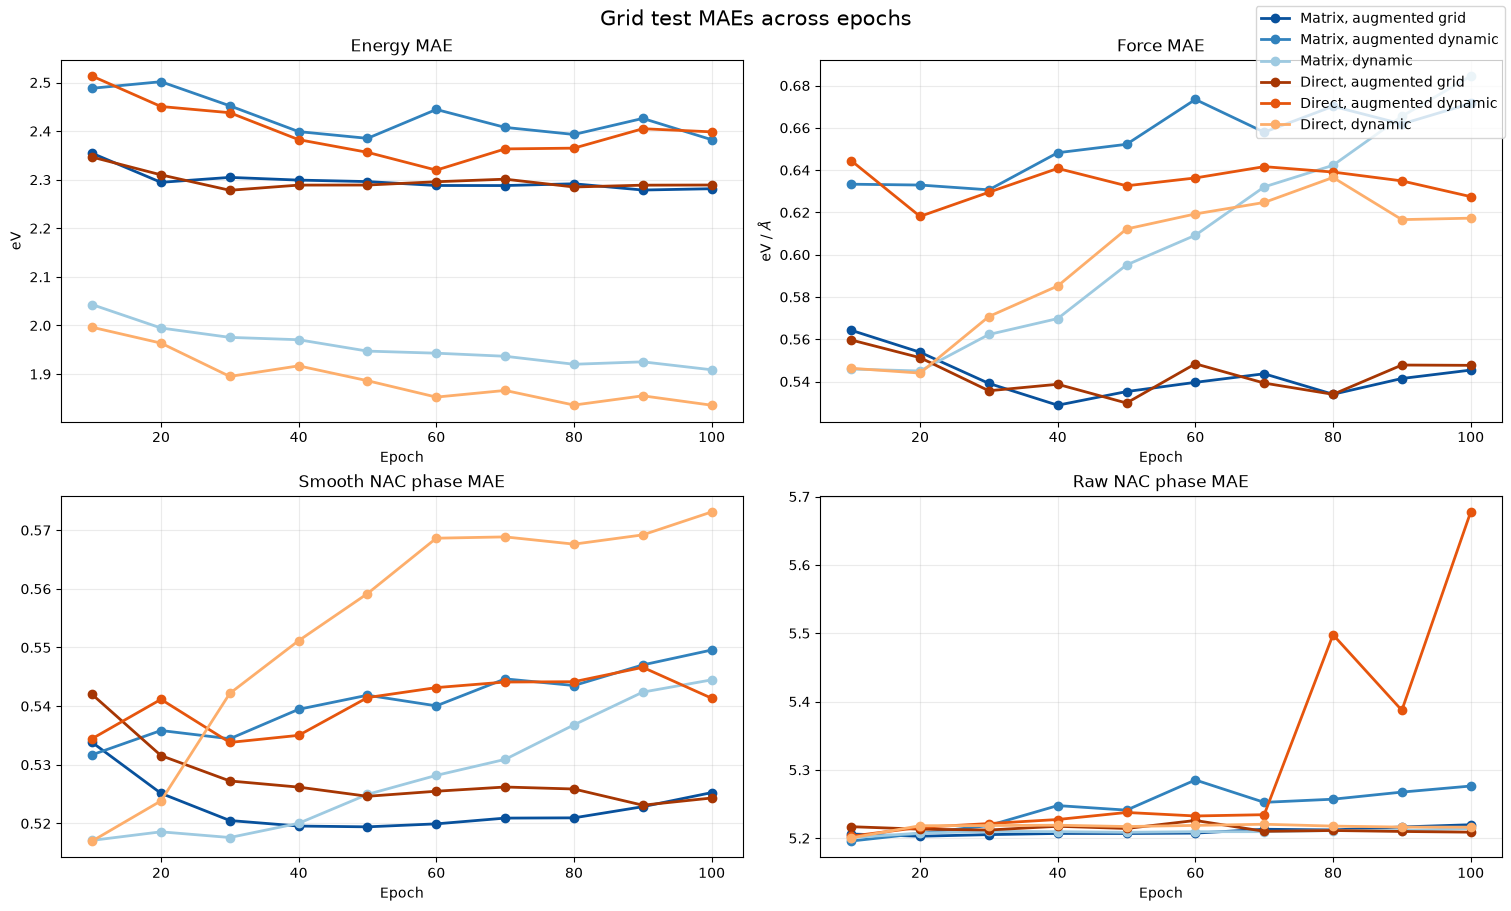

In [34]:
# Manual grid-test MAEs across checkpoint epochs. Paste one list per metric and run.
import matplotlib.pyplot as plt

CHECKPOINT_EPOCHS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
RUNS = [15, 16, 17, 18, 19, 20]
RUN_LABELS = {
    15: 'Matrix, augmented grid',
    16: 'Matrix, augmented dynamic',
    17: 'Matrix, dynamic',
    18: 'Direct, augmented grid',
    19: 'Direct, augmented dynamic',
    20: 'Direct, dynamic',
}
RUN_COLORS = {
    15: '#08519C',  # dark blue
    16: '#3182BD',  # medium blue
    17: '#9ECAE1',  # light blue
    18: '#A63603',  # dark orange
    19: '#E6550D',  # medium orange
    20: '#FDAE6B',  # light orange
}
METRICS = {
    'energy_mae_ev': ('Energy MAE', 'eV'),
    'force_mae_ev_per_ang': ('Force MAE', r'eV / $\AA$'),
    'smooth_nac_phase_mae': ('Smooth NAC phase MAE', ''),
    'raw_nac_phase_mae': ('Raw NAC phase MAE', ''),
}

# Paste MAE lists here. Each list must have one value per CHECKPOINT_EPOCHS entry.
# Example format: [2.51313210, 2.45060134, 2.43784809, ...]
GRID_TEST_RESULTS = {
    15: {'energy_mae_ev': [2.35437942, 2.29456258, 2.30471325, 2.29914474, 2.29609179, 2.28805041, 2.28792572, 2.29158425, 2.27870631, 2.28141046], 
         'force_mae_ev_per_ang': [0.56423837, 0.55384690, 0.53910524, 0.52878433, 0.53523499, 0.53960353, 0.54366136, 0.53396314, 0.54141778, 0.54539931], 
         'smooth_nac_phase_mae': [0.53381151, 0.52513194, 0.52049387, 0.51955253, 0.51941681, 0.51992452, 0.52090663, 0.52094966, 0.52285200, 0.52525347], 
         'raw_nac_phase_mae': [5.20609808, 5.20283699, 5.20519257, 5.20692587, 5.20687389, 5.20741940, 5.21304798, 5.21207619, 5.21639967, 5.21967888]},
    16: {'energy_mae_ev': [2.48814654, 2.50164938, 2.45204997, 2.39896202, 2.38508010, 2.44449449, 2.40761161, 2.39305902, 2.42609882, 2.38229108], 
         'force_mae_ev_per_ang': [0.63334227, 0.63295156, 0.63068163, 0.64822954, 0.65222102, 0.67343682, 0.65794754, 0.67020625, 0.66183084, 0.67154759], 
         'smooth_nac_phase_mae': [0.53170598, 0.53584218, 0.53443503, 0.53945714, 0.54185963, 0.54004711, 0.54464960, 0.54351217, 0.54702753, 0.54956847], 
         'raw_nac_phase_mae': [5.19580078, 5.20691824, 5.21851683, 5.24769831, 5.24105787, 5.28520775, 5.25245142, 5.25705481, 5.26744318, 5.27631569]},
    17: {'energy_mae_ev': [2.04294038, 1.99477303, 1.97547245, 1.97062588, 1.94721317, 1.94293630, 1.93660319, 1.92013133, 1.92514801, 1.90878737], 
         'force_mae_ev_per_ang': [0.54589385, 0.54497892, 0.56224155, 0.56977087, 0.59513944, 0.60920167, 0.63206583, 0.64228910, 0.66546315, 0.68447691], 
         'smooth_nac_phase_mae': [0.51710874, 0.51856667, 0.51759762, 0.52001983, 0.52494973, 0.52819079, 0.53091919, 0.53680855, 0.54238987, 0.54447758], 
         'raw_nac_phase_mae': [5.20086527, 5.20735788, 5.20990562, 5.20953989, 5.20863724, 5.20949936, 5.20952177, 5.21115351, 5.21123266, 5.21418524]},
    18: {'energy_mae_ev': [2.34651065, 2.30994582, 2.27819300, 2.28885555, 2.28898525, 2.29575658, 2.30107284, 2.28495479, 2.28871751, 2.28904963], 
         'force_mae_ev_per_ang': [0.55965084, 0.55128020, 0.53562111, 0.53869075, 0.52981907, 0.54837799, 0.53926229, 0.53393221, 0.54779154, 0.54764760], 
         'smooth_nac_phase_mae': [0.54198939, 0.53156829, 0.52724141, 0.52619195, 0.52462590, 0.52548939, 0.52620763, 0.52586710, 0.52310646, 0.52433467], 
         'raw_nac_phase_mae': [5.21679544, 5.21317434, 5.21197081, 5.21740723, 5.21418428, 5.22592545, 5.21005392, 5.21123934, 5.20981884, 5.20880508]},
    19: {'energy_mae_ev': [2.51313210, 2.45060134, 2.43784809, 2.38241029, 2.35631227, 2.31966782, 2.36333537, 2.36491942, 2.40489411, 2.39843488], 
         'force_mae_ev_per_ang': [0.64449602, 0.61812067, 0.62953615, 0.64080846, 0.63259220, 0.63630700, 0.64165306, 0.63909757, 0.63490897, 0.62746429], 
         'smooth_nac_phase_mae': [0.53445762, 0.54115593, 0.53380984, 0.53501683, 0.54145885, 0.54315919, 0.54410738, 0.54416490, 0.54661155, 0.54134923], 
         'raw_nac_phase_mae': [5.20295477, 5.21577120, 5.22138977, 5.22732639, 5.23763609, 5.23250866, 5.23437881, 5.49782181, 5.38718653, 5.67752314]},
    20: {'energy_mae_ev': [1.99629271, 1.96366978, 1.89510167, 1.91685772, 1.88629973, 1.85255682, 1.86628258, 1.83617353, 1.85521984, 1.83586657], 
         'force_mae_ev_per_ang': [0.54626602, 0.54398292, 0.57073849, 0.58519000, 0.61215681, 0.61927879, 0.62470561, 0.63652962, 0.61658829, 0.61727732], 
         'smooth_nac_phase_mae': [0.51699477, 0.52384108, 0.54217571, 0.55116111, 0.55918890, 0.56863600, 0.56885731, 0.56762135, 0.56920254, 0.57310998], 
         'raw_nac_phase_mae': [5.20043898, 5.21825552, 5.21847343, 5.21898746, 5.21702957, 5.21870041, 5.22040701, 5.21768188, 5.21622562, 5.21615219]},
}

for run in RUNS:
    for metric_key in METRICS:
        maes = GRID_TEST_RESULTS[run][metric_key]
        if len(maes) != len(CHECKPOINT_EPOCHS):
            raise ValueError(
                f'run_{run} {metric_key} has {len(maes)} values; expected {len(CHECKPOINT_EPOCHS)}.'
            )

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
for axis, (metric_key, (metric_label, unit)) in zip(axes.flat, METRICS.items()):
    for run in RUNS:
        axis.plot(
            CHECKPOINT_EPOCHS, GRID_TEST_RESULTS[run][metric_key],
            marker='o', linewidth=2,
            label=RUN_LABELS[run], color=RUN_COLORS[run],
        )
    axis.set_title(metric_label)
    axis.set_xlabel('Epoch')
    axis.set_ylabel(unit)
    axis.grid(alpha=0.25)

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper right')
fig.suptitle('Grid test MAEs across epochs', fontsize=15)
plt.show()


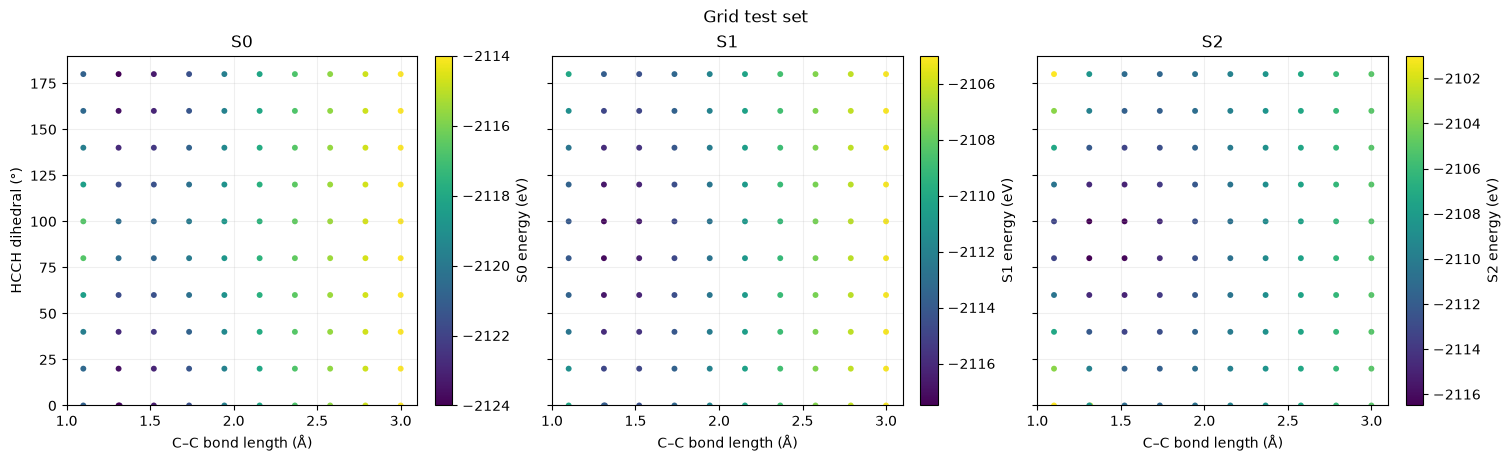

In [41]:
# CASSCF energy surfaces on the extended ethene grid.
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np

# Works when the notebook is run either from the repository root or notebooks/.
XYZ_GRID = next(
    (path for path in (
        Path("data/A01_ethene/static/A01_ethene_grid_static_CASSCF_101_grid.xyz"),
        Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_101_grid.xyz"),
    ) if path.is_file()),
    None,
)
if XYZ_GRID is None:
    raise FileNotFoundError("Could not find the augmented ethene XYZ grid.")

ethene_atoms = ase.io.read(XYZ_GRID, index=":")
energies = np.vstack([
    np.asarray(atoms.info["REF_energy"], dtype=float).reshape(-1)
    for atoms in ethene_atoms
])
if energies.shape[1] != 3:
    raise ValueError(f"Expected S0, S1, and S2 energies; got {energies.shape[1]} states.")

# Atom ordering in this ethene XYZ is C, C, H, H, H, H.
cc_bond_lengths = np.asarray([atoms.get_distance(0, 1) for atoms in ethene_atoms])
# Fold the 0–360° convention returned by ASE into the equivalent 0–180° torsion.
hcch_dihedrals = np.asarray([atoms.get_dihedral(2, 0, 1, 3) for atoms in ethene_atoms])
hcch_dihedrals = np.minimum(hcch_dihedrals, 360.0 - hcch_dihedrals)

# Fixed state-specific scales match the CASSCF grid heatmaps.
ENERGY_LIMITS = [(-2124, -2114), (-2117.5, -2105), (-2116.5, -2101)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True, constrained_layout=True)
for state, ax in enumerate(axes):
    scatter = ax.scatter(
        cc_bond_lengths, hcch_dihedrals, c=energies[:, state],
        cmap="viridis", vmin=ENERGY_LIMITS[state][0], vmax=ENERGY_LIMITS[state][1],
        s=18, linewidths=0,
    )
    ax.set(
        title=f"S{state}", xlabel="C–C bond length (Å)",
        xlim=(1.0, 3.1), ylim=(0, 190),
    )
    ax.grid(alpha=0.2)
    fig.colorbar(scatter, ax=ax, label=f"S{state} energy (eV)")

axes[0].set_ylabel("HCCH dihedral (°)")
fig.suptitle("Grid test set")
plt.show()
